/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))
/global/homes/n/nishavk/cosmoprimo/cosmoprimo/eisenstein_hu.py:25: UserWarni

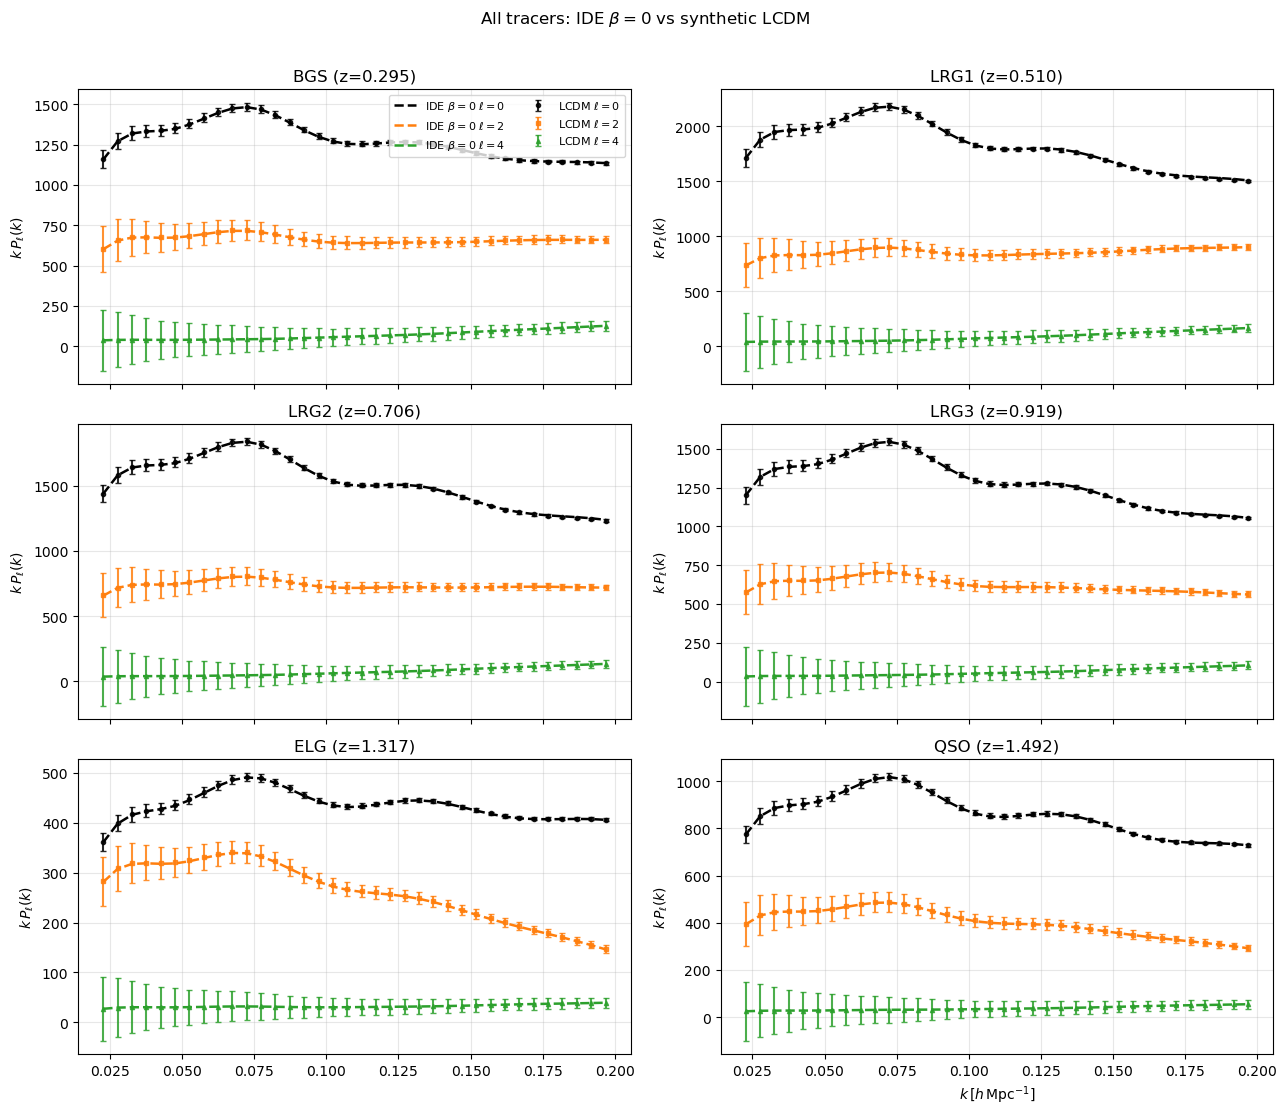

In [ ]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/global/homes/n/nishavk/FOLPSpipe/')
sys.path.insert(0, '/global/homes/n/nishavk/fkptjax_muMG/src/')
sys.path.insert(0, '/global/homes/n/nishavk/isitIDE/')
sys.path.insert(0, '/global/homes/n/nishavk/desilike/')
sys.path.insert(0, '/global/homes/n/nishavk/cosmoprimo/')

# -----------------------------
# Optional JAX settings (debug)
# -----------------------------
os.environ["JAX_DISABLE_JIT"] = "1"
# os.environ.setdefault("JAX_DISABLE_JIT", "1")  # set "0" for speed once validated
import jax
jax.config.update("jax_disable_jit", True)
jax.config.update("jax_enable_x64", True)

# -----------------------------
# desilike / cosmoprimo imports
# -----------------------------
from desilike.theories import Cosmoprimo
from desilike.theories.galaxy_clustering import DirectPowerSpectrumTemplate
from desilike.theories.galaxy_clustering import fkptjaxTracerPowerSpectrumMultipoles
from desilike import parameter
from cosmoprimo.fiducial import DESI

from pathlib import Path

synthetic_data_dir = Path("/global/homes/n/nishavk/desilike/MG/synthetic_data")
k_fixed = np.array([
    0.02271, 0.02768277, 0.03265554, 0.03762831, 0.04260109,
    0.04757386, 0.05254663, 0.05751940, 0.06249217, 0.06746494,
    0.07243771, 0.07741049, 0.08238326, 0.08735603, 0.09232880,
    0.09730157, 0.1022743,  0.1072471,  0.1122199,  0.1171927,
    0.1221654,  0.1271382,  0.1321110,  0.1370837,  0.1420565,
    0.1470293,  0.1520021,  0.1569748,  0.1619476,  0.1669204,
    0.1718931,  0.1768659,  0.1818387,  0.1868115,  0.1917842,
    0.1967570,
])

ells_plot = (0, 2, 4)

# ============================================================
# matching cosmology + EFT settings to the synthetic data
# ============================================================

IDE_model = "IDE"
ide_variant = "IDEModel1"
beyond_eds = True     # set False for EdS kernels
rescale_PS = False

# ---- nuisance params (STANDARD basis names) ----
freedom = "max"
prior_basis = "standard"   # alias -> standard_folps

b1 = 1.5
b2 = -0.5247206065
bs2 = 0.0
b3nl = 0.0
alpha0, alpha2, alpha4 = 3.0, -1.0, 0.0
ctilde = 0.0
alpha0shot, alpha2shot = 0.08, -2.0
pshotp = 10000.0

# ---- cosmology ----
h      = 0.6736
ombh2  = 0.02237
omch2  = 0.12
omnuh2 = 0.06 / 93.14
Om     = (ombh2 + omch2 + omnuh2) / h**2

As   = 2.083e-09
ns   = 0.9649
Neff = 3.046

Omfid = 0.31519172481908053  # only kept for reference


# Match synthetic-data tracer setup
tracer_settings = {
    "BGS":  {"z_pk": 0.295, "b1": 1.5, "b2": -0.5247206065},
    "LRG1": {"z_pk": 0.51,  "b1": 2.1, "b2": -0.9955559762},
    "LRG2": {"z_pk": 0.706, "b1": 2.1, "b2": -1.129586780},
    "LRG3": {"z_pk": 0.919, "b1": 2.1, "b2": -1.073936223},
    "ELG":  {"z_pk": 1.317, "b1": 1.2, "b2": 0.03376361031},
    "QSO":  {"z_pk": 1.492, "b1": 2.1, "b2": -0.7104953308},
}


def compute_ide_beta0_multipoles_for_tracer(tracer, vals):
    """Compute IDE(beta=0) P0,P2,P4 with fkptjax for one tracer."""
    z = vals["z_pk"]
    b1_local = vals["b1"]
    b2_local = vals["b2"]

    cosmo_local = Cosmoprimo(engine="isitide", dark_energy_model=ide_variant, N_eff=Neff, m_ncdm=[0.06])
    cosmo_local.init.params["h"].update(value=h)
    cosmo_local.init.params["omega_b"].update(value=ombh2)
    cosmo_local.init.params["omega_cdm"].update(value=omch2)
    cosmo_local.init.params["logA"].update(value=float(np.log(1e10 * As)))
    cosmo_local.init.params["n_s"].update(value=ns)

    if "beta" not in cosmo_local.init.params:
        cosmo_local.init.params.data.append(parameter.Parameter(basename="beta", value=0.0, fixed=True))
    cosmo_local.init.params["beta"].update(value=0.0, fixed=True)

    template_local = DirectPowerSpectrumTemplate(z=float(z), fiducial=DESI(), cosmo=cosmo_local)
    template_local.init.update(with_now="peakaverage")

    theory_local = fkptjaxTracerPowerSpectrumMultipoles()
    theory_local.init.update(
        freedom=freedom,
        prior_basis=prior_basis,
        tracer=tracer,
        template=template_local,
        k=k_fixed,
        ells=list(ells_plot),
        model=IDE_model,
        ide_variant=ide_variant,
        beyond_eds=bool(beyond_eds),
        rescale_PS=bool(rescale_PS),
        shotnoise=pshotp,
    )

    fixed_vals_local = {
        "b1": b1_local,
        "b2": b2_local,
        "bs2": 0.0,
        "b3nl": 0.0,
        "alpha0": alpha0,
        "alpha2": alpha2,
        "alpha4": alpha4,
        "ctilde": ctilde,
        "alpha0shot": alpha0shot,
        "alpha2shot": alpha2shot,
    }
    for name, val in fixed_vals_local.items():
        if name in theory_local.init.params:
            theory_local.init.params[name].update(fixed=True, value=float(val))

    P = np.asarray(theory_local())
    if P.ndim == 2:
        P0, P2, P4 = P[0], P[1], P[2]
    elif P.ndim == 1:
        Nk = k_fixed.size
        P0, P2, P4 = P[0 * Nk:1 * Nk], P[1 * Nk:2 * Nk], P[2 * Nk:3 * Nk]
    else:
        raise RuntimeError(f"Unexpected theory output shape {P.shape} for tracer {tracer}")

    return P0, P2, P4


fig, axs = plt.subplots(3, 2, figsize=(13, 11), sharex=True)
axs = axs.flatten()

for i, (tracer, vals) in enumerate(tracer_settings.items()):
    # Compute IDE beta=0 multipoles
    P0_ide, P2_ide, P4_ide = compute_ide_beta0_multipoles_for_tracer(tracer, vals)

    # Load synthetic LCDM files
    k_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_LCDM_k.txt")
    P_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_LCDM_P0P2P4.txt")
    C_syn = np.loadtxt(synthetic_data_dir / f"{tracer}_LCDM_cov.txt")

    Nk = k_syn.size
    if P_syn.size != 3 * Nk:
        raise RuntimeError(f"{tracer}: P0P2P4 size mismatch ({P_syn.size} vs {3 * Nk})")
    if C_syn.shape != (3 * Nk, 3 * Nk):
        raise RuntimeError(f"{tracer}: covariance shape mismatch {C_syn.shape}, expected {(3 * Nk, 3 * Nk)}")

    if not np.allclose(k_fixed, k_syn, rtol=0.0, atol=1e-12):
        max_dk = np.max(np.abs(k_fixed - k_syn))
        raise RuntimeError(f"{tracer}: k-grid mismatch (max |dk|={max_dk:.3e})")

    P0_syn = P_syn[0 * Nk:1 * Nk]
    P2_syn = P_syn[1 * Nk:2 * Nk]
    P4_syn = P_syn[2 * Nk:3 * Nk]

    err0 = np.sqrt(np.diag(C_syn[0 * Nk:1 * Nk, 0 * Nk:1 * Nk]))
    err2 = np.sqrt(np.diag(C_syn[1 * Nk:2 * Nk, 1 * Nk:2 * Nk]))
    err4 = np.sqrt(np.diag(C_syn[2 * Nk:3 * Nk, 2 * Nk:3 * Nk]))

    ax = axs[i]

    # Synthetic LCDM with covariance errors
    ax.errorbar(k_syn, k_syn * P0_syn, yerr=k_syn * err0, fmt="o", ms=3, capsize=2,
                color="k", alpha=0.85, label=r"LCDM $\ell=0$")
    ax.errorbar(k_syn, k_syn * P2_syn, yerr=k_syn * err2, fmt="s", ms=3, capsize=2,
                color="tab:orange", alpha=0.85, label=r"LCDM $\ell=2$")
    ax.errorbar(k_syn, k_syn * P4_syn, yerr=k_syn * err4, fmt="^", ms=3, capsize=2,
                color="tab:green", alpha=0.85, label=r"LCDM $\ell=4$")

    # IDE beta=0 curves
    ax.plot(k_fixed, k_fixed * P0_ide, "--", lw=1.8, color="k", label=r"IDE $\beta=0$ $\ell=0$")
    ax.plot(k_fixed, k_fixed * P2_ide, "--", lw=1.8, color="tab:orange", label=r"IDE $\beta=0$ $\ell=2$")
    ax.plot(k_fixed, k_fixed * P4_ide, "--", lw=1.8, color="tab:green", label=r"IDE $\beta=0$ $\ell=4$")

    ax.set_title(f"{tracer} (z={vals['z_pk']:.3f})")
    ax.set_ylabel(r"$k\,P_\ell(k)$")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(ncols=2, fontsize=8)

axs[-1].set_xlabel(r"$k\,[h\,\mathrm{Mpc}^{-1}]$")
fig.suptitle("All tracers: IDE $\\beta=0$ vs synthetic LCDM", y=1.01)
fig.tight_layout()
plt.savefig('IDE_test_with_synthetic.png', dpi=300)
plt.show()
